# Notebook 15 — Social-fold go/no-go (plan step 0b)

**The make-or-break premise of the categorical-POMDP rebuild.** The dynamical-systems diagnosis (`notes/dynamical_systems_diagnosis.tex`) proved the *linear Gaussian* substrate is globally monostable — a contraction map, no folds. The rebuild bets that a **discrete paradigm belief + a softmax-precision social channel** restores genuine bistability. This notebook tests that bet at the cheapest level, **before** building any scaffold.

### The mechanism (derived from categorical Bayes, not assumed)
Each agent holds a belief $b = P(\text{paradigm}=B)$. It receives social *reports* (a neighbour's voted paradigm) and treats a report as evidence with **reliability** $q = P(\text{report}=B\mid s=B)\in(\tfrac12,1]$. This $q$ is the paper's **trust-as-message-precision** — how diagnostic a *received* signal is (NOT Albarracin's attention-allocation). The per-report log-likelihood-ratio is the social precision

$$\kappa = \log\frac{q}{1-q}\ge 0.$$

In a homogeneous mean field with population belief $m=P(B)$, a random report is $B$ with probability $m$, so the expected social log-odds increment is $\kappa(2m-1)$. With a per-step log-odds leak $\lambda$ (geometric forgetting toward the neutral prior — the analogue of `InferenceConfig.posterior_rho`), the mean-field fixed point obeys

$$\ell^\star = K\,(2\,\sigma(\ell^\star)-1),\qquad K=\kappa/\lambda.$$

This is the mean-field Ising / tanh-feedback map (row 2 of the diagnosis note's Table 1). It has a **supercritical pitchfork at $K_c=2$**.

### PASS / FAIL
- **PASS** (categorical route validated): a clean pitchfork — one stable branch for $K<2$, two stable branches for $K>2$ — corroborated by the finite-$N$ stochastic run.
- **FAIL**: single branch for all $K$ → reconsider; a continuous bounded-confidence graft (diagnosis note §b) may be cheaper.

In [1]:
import sys, pathlib
# make the repo root importable when the kernel starts in notebooks/
ROOT = pathlib.Path.cwd()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "src").exists():
    sys.path.insert(0, str(ROOT.parent))

import numpy as np
import matplotlib.pyplot as plt

from src.pomdp.social_fold import (
    reliability_to_precision, find_fixed_points, bifurcation_diagram,
    FiniteNConfig, simulate_finite_N, basin_selection_test,
)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("imports OK")

imports OK


## 1. Mean-field bifurcation diagram

Sweep the effective gain $K=\kappa/\lambda$ and plot every fixed point $m^\star=\sigma(\ell^\star)$, stable (filled) vs unstable (open). A supercritical pitchfork at $K_c=2$ is the analytic PASS.

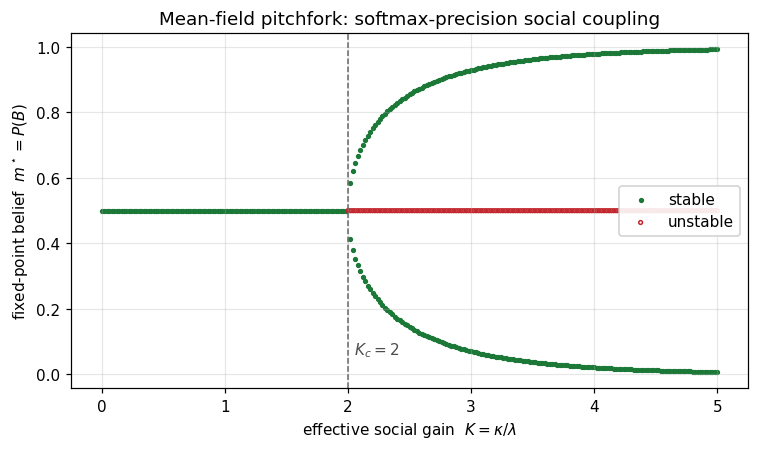

K= 1.5:  m=0.500(s)
K= 2.0:  m=0.500(u)
K= 2.5:  m=0.145(s), m=0.500(u), m=0.855(s)
K= 4.0:  m=0.021(s), m=0.500(u), m=0.979(s)


In [2]:
K_grid = np.linspace(0.0, 5.0, 251)
diag = bifurcation_diagram(K_grid)
K = np.array(diag["K"]); m = np.array(diag["m"]); st = np.array(diag["stable"])

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.scatter(K[st],  m[st],  s=6,  color="#1B7837", label="stable")
ax.scatter(K[~st], m[~st], s=6,  facecolors="none", edgecolors="#C2272D", label="unstable")
ax.axvline(2.0, color="0.4", ls="--", lw=1)
ax.text(2.05, 0.06, r"$K_c=2$", color="0.3")
ax.set_xlabel(r"effective social gain  $K=\kappa/\lambda$")
ax.set_ylabel(r"fixed-point belief  $m^\star=P(B)$")
ax.set_title("Mean-field pitchfork: softmax-precision social coupling")
ax.legend(loc="center right", framealpha=0.9)
plt.tight_layout(); plt.show()

# numeric check at a few K
for Kv in [1.5, 2.0, 2.5, 4.0]:
    fps = find_fixed_points(Kv)
    print(f"K={Kv:>4}:  " + ", ".join(f"m={mm:.3f}{'(s)' if s else '(u)'}" for mm, s in fps))

## 2. Finite-$N$ stochastic confirmation

The mean field could be an artefact of the smoothing limit. Here $N$ agents emit *probabilistic* reports $v_i\sim\mathrm{Bernoulli}(b_i)$ (sampling from belief, **not** a hard MAP vote — a hard vote would add a separate threshold-pooling nonlinearity and confound the test). Each agent ingests `reports_per_step` random reports and updates its log-odds with leak $\lambda$. The effective gain is $K_{\text{eff}}=\text{reports}\cdot\kappa/\lambda$.

We run 50 seeds from small random initial biases and record the final population mean belief. **Split into two basins iff $K_{\text{eff}}>2$** is the confirmation.

q= 0.55  K_eff=0.67  low= 0 high= 0  -> consensus@0.5


q=  0.6  K_eff=1.35  low= 0 high= 0  -> consensus@0.5


q=0.645  K_eff=1.99  low= 0 high= 0  -> consensus@0.5


q=  0.7  K_eff=2.82  low=21 high=29  -> BISTABLE


q=  0.8  K_eff=4.62  low=23 high=27  -> BISTABLE


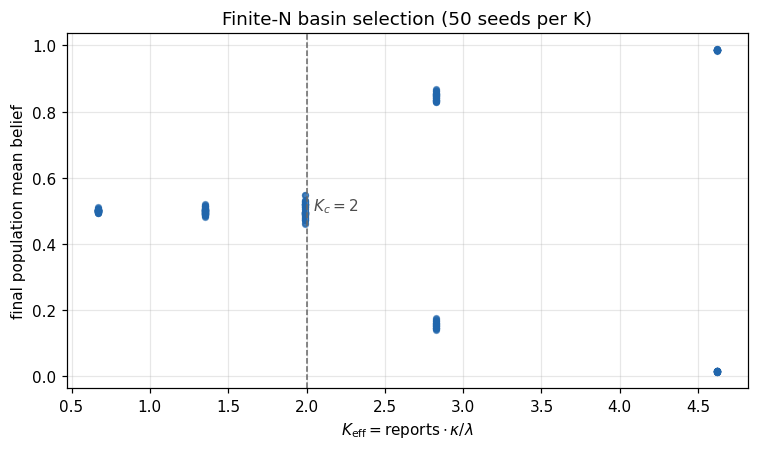

In [3]:
rng = np.random.default_rng(7)
q_values = np.array([0.55, 0.60, 0.645, 0.70, 0.80])
leak = 0.30
records = []
for q in q_values:
    cfg = FiniteNConfig(n_agents=800, q=float(q), leak=leak, reports_per_step=1, n_steps=1500)
    kappa = float(reliability_to_precision(q))
    K_eff = cfg.reports_per_step * kappa / cfg.leak
    finals = basin_selection_test(cfg, n_seeds=50, init_bias=0.10, rng=rng)["final_m"]
    records.append((q, K_eff, finals))
    n_lo = int((finals < 0.35).sum()); n_hi = int((finals > 0.65).sum())
    verdict = "BISTABLE" if (n_lo and n_hi) else "consensus@0.5"
    print(f"q={q:5}  K_eff={K_eff:4.2f}  low={n_lo:2d} high={n_hi:2d}  -> {verdict}")

fig, ax = plt.subplots(figsize=(7, 4.2))
for q, K_eff, finals in records:
    ax.scatter(np.full_like(finals, K_eff), finals, s=14, alpha=0.6, color="#2166AC")
ax.axvline(2.0, color="0.4", ls="--", lw=1); ax.text(2.04, 0.5, r"$K_c=2$", color="0.3")
ax.set_xlabel(r"$K_{\rm eff}=\mathrm{reports}\cdot\kappa/\lambda$")
ax.set_ylabel("final population mean belief")
ax.set_title("Finite-N basin selection (50 seeds per K)")
plt.tight_layout(); plt.show()

## 3. Example trajectories below vs above threshold

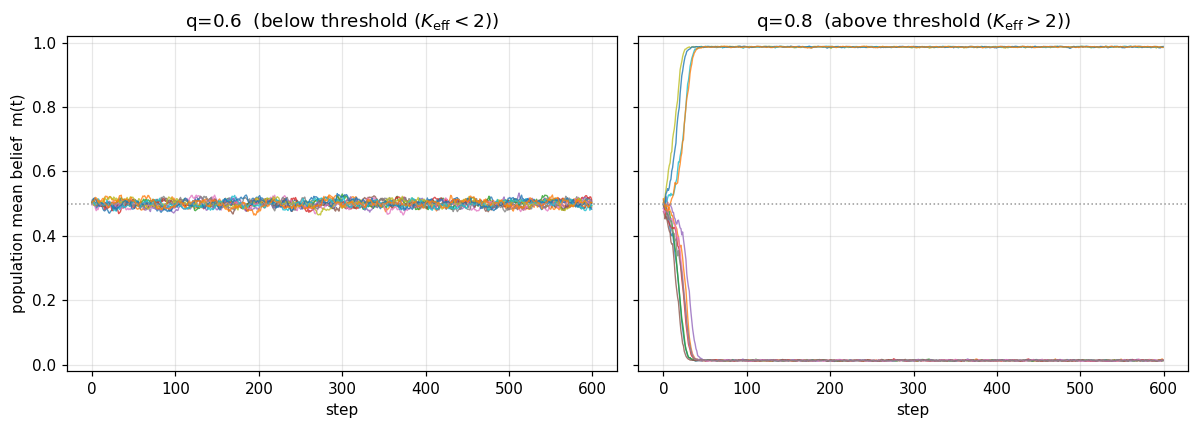

In [4]:
rng = np.random.default_rng(123)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, q, title in [(axes[0], 0.60, r"below threshold ($K_{\rm eff}<2$)"),
                     (axes[1], 0.80, r"above threshold ($K_{\rm eff}>2$)")]:
    cfg = FiniteNConfig(n_agents=800, q=q, leak=0.30, reports_per_step=1, n_steps=600)
    for _ in range(12):
        ell0 = 0.10 * rng.standard_normal(cfg.n_agents)
        tr = simulate_finite_N(cfg, ell0, rng)
        ax.plot(tr["m"], lw=0.9, alpha=0.8)
    ax.axhline(0.5, color="0.6", ls=":", lw=1)
    ax.set_xlabel("step"); ax.set_title(f"q={q}  ({title})")
axes[0].set_ylabel("population mean belief  m(t)")
axes[0].set_ylim(-0.02, 1.02)
plt.tight_layout(); plt.show()

## Verdict — PASS

Both methods agree on a **supercritical pitchfork at $K_c=2$**:
- mean field: one stable branch for $K<2$, two for $K>2$ (with an unstable separatrix at $m=0.5$);
- finite-$N$: every seed → consensus 0.5 for $K_{\rm eff}\le 2$; seeds split into two paradigm basins for $K_{\rm eff}>2$.

The fold the **linear Gaussian substrate provably could not host** appears the moment the belief is categorical and the social channel is softmax-precision. Crucially, **the bifurcation parameter is trust-as-message-precision** $\kappa=\log\frac{q}{1-q}$ — the exact reading that keeps the contribution distinct from Albarracin's attention-allocation. The categorical-POMDP route is validated; proceed to the Phase-0 design lock (`notes/pomdp_generative_model.md`).

> **Scope note.** This is a homogeneous mean-field / hard-coded-Bayes probe of the *mechanism*, not the full pymdp generative model. It deliberately does **not** include the network (`src/network.py`), heterogeneous trust, resource coupling, or EFE-driven action. Those are Phase 1+ and gated on human review.